In [1]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# Add the directory containing deepsets_classifier.py to the Python path
current_path = os.getcwd()
print(current_path)
sys.path.append(os.path.join(current_path, 'classifier'))

from deepsets_classifier import *
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

/Users/lukapuslar/Desktop/other/ASEF/Project/Code/RSA/RSA/src


In [2]:
class ObservableDataset(Dataset):
	"""
	Converts observable dataset into PyTorch syntax.
	"""
	def __init__(self, data, mask = None):
		self.data = data
		# if mask == None:
		# 	self.masks  = (data != 0).any(dim=-1)
		# else:
		# 	self.masks = mask
		
	def __len__(self):
		return self.data.shape[0]

	def __getitem__(self, idx):
		sample = self.data[idx]
		# mask = self.masks[idx]
		return sample

In [3]:
# Load hadron and accept-reject data
exp_hadrons_PATH = '../data/structured_data/pgun_qqbar_hadrons_a_0.68_b_0.98_sigma_0.335_N_1e4.npy'
sim_hadrons_PATH = '../data/structured_data/pgun_qqbar_hadrons_a_0.72_b_0.88_sigma_0.335_N_1e4.npy'

In [4]:
def prescale(exp_data, sim_data, axes=(0, 1)):
    """
    Prescale the experimental and simulated data using the combined mean and standard deviation.

    Args:
        exp_data (np.ndarray): The experimental data.
        sim_data (np.ndarray): The simulated data.
        axes (tuple): The axes along which to calculate the mean and standard deviation.

    Returns:
        np.ndarrays: The prescaled experimental and simulated data.
    """
    # Mask to identify non-padded entries (i.e., entries that are not [0.0, 0.0, 0.0, 0.0])
    non_padded_mask_exp = ~(np.all(exp_data == 0, axis=-1))
    non_padded_mask_sim = ~(np.all(sim_data == 0, axis=-1))
    
    # Flatten the non-padded parts of the datasets along the specified axes for mean/std calculation
    combined_data = np.concatenate([exp_data[non_padded_mask_exp], sim_data[non_padded_mask_sim]], axis=0)
    combined_mean = combined_data.mean(axis=0)
    print("Mean:", combined_mean)
    combined_std = combined_data.std(axis=0)

    # Scale only the non-padded entries using the combined mean and std
    exp_data_scaled = np.copy(exp_data)
    sim_data_scaled = np.copy(sim_data)
    exp_data_scaled[non_padded_mask_exp] = (exp_data[non_padded_mask_exp] - combined_mean) / combined_std
    sim_data_scaled[non_padded_mask_sim] = (sim_data[non_padded_mask_sim] - combined_mean) / combined_std
    
    return exp_data_scaled, sim_data_scaled

In [5]:
# Load the hadron data
exp_hadrons = np.load(exp_hadrons_PATH, mmap_mode="r")
sim_hadrons = np.load(sim_hadrons_PATH, mmap_mode="r")

print('Experimental hadron data shape:', exp_hadrons.shape)
print('Simulated hadron data shape:', sim_hadrons.shape)

# Extract the hadron multiplicity
N = 10000
exp_mult = np.array([len(exp_hadrons[i,:][np.abs(exp_hadrons[i,:,0]) > 0.0]) for i in range(N)])
sim_mult = np.array([len(sim_hadrons[i,:][np.abs(sim_hadrons[i,:,0]) > 0.0]) for i in range(N)])

# Find the maximum multiplicity
min_mult = min(exp_mult.min(), sim_mult.min())
max_mult = max(exp_mult.max(), sim_mult.max())
print("Max multiplicity:", max_mult)

# Resize the zero-padding to the maximum multiplicity
exp_hadrons = exp_hadrons[:, :max_mult, :]
sim_hadrons = sim_hadrons[:, :max_mult, :]

# Extract (px, py, pz)
px_exp, py_exp, pz_exp = exp_hadrons[..., 0], exp_hadrons[..., 1], exp_hadrons[..., 2]
px_sim, py_sim, pz_sim = sim_hadrons[..., 0], sim_hadrons[..., 1], sim_hadrons[..., 2]

# Create masks for non-zero momentum entries
mask_exp = (px_exp != 0) | (py_exp != 0) | (pz_exp != 0)
mask_sim = (px_sim != 0) | (py_sim != 0) | (pz_sim != 0)

# Calculate transverse momentum (pT)
pt_exp = np.sqrt(px_exp**2 + py_exp**2)
pt_sim = np.sqrt(px_sim**2 + py_sim**2)

# Initialize arrays for the results with zeros
phi_exp = np.zeros_like(pt_exp)
phi_sim = np.zeros_like(pt_sim)
eta_exp = np.zeros_like(pt_exp)
eta_sim = np.zeros_like(pt_sim)

# Apply the calculations only where the mask is True (non-zero momentum)
phi_exp[mask_exp] = np.arctan2(py_exp[mask_exp], px_exp[mask_exp])
phi_sim[mask_sim] = np.arctan2(py_sim[mask_sim], px_sim[mask_sim])

theta_exp = np.arctan2(pt_exp[mask_exp], pz_exp[mask_exp])
theta_sim = np.arctan2(pt_sim[mask_sim], pz_sim[mask_sim])

eta_exp[mask_exp] = -np.log(np.tan(theta_exp / 2))
eta_sim[mask_sim] = -np.log(np.tan(theta_sim / 2))

# Define the new angular observable array (pT, phi, eta)
exp_obs = np.stack([pt_exp, phi_exp, eta_exp], axis=-1)
sim_obs = np.stack([pt_sim, phi_sim, eta_sim], axis=-1)

# Print dataset shapes
print('Experimental observable shape:', exp_obs.shape)
print('Simulated observable shape:', sim_obs.shape)

# Prescale the data
N_events = int(10000)
exp_obs, sim_obs = prescale(exp_obs[0:N_events], sim_obs[0:N_events])

# Convert into torch objects
exp_obs = torch.Tensor(exp_obs.copy())
sim_obs = torch.Tensor(sim_obs.copy())

Experimental hadron data shape: (10000, 75, 5)
Simulated hadron data shape: (10000, 75, 5)
Max multiplicity: 29
Experimental observable shape: (10000, 29, 3)
Simulated observable shape: (10000, 29, 3)
Mean: [ 0.40791564 -0.00370054  0.57467334]


In [6]:
from sklearn.model_selection import train_test_split
batch_size = 100

# Split data and prepare for training
sim_obs_train, sim_obs_test, exp_obs_train, exp_obs_test = train_test_split(sim_obs, exp_obs, test_size=0.2, random_state=42)
sim_obs_val, sim_obs_test, exp_obs_val, exp_obs_test = train_test_split(sim_obs_test, exp_obs_test, test_size=0.5, random_state=42)

sim_obs_train, sim_obs_test, sim_bos_val = ObservableDataset(sim_obs_train), ObservableDataset(sim_obs_test), ObservableDataset(sim_obs_val)
exp_obs_train, exp_obs_test, exp_obs_val = ObservableDataset(exp_obs_train), ObservableDataset(exp_obs_test), ObservableDataset(exp_obs_val)

sim_obs_train_loader, sim_obs_test_loader, sim_obs_val_loader = DataLoader(sim_obs_train, batch_size=batch_size), DataLoader(sim_obs_test, batch_size=batch_size), DataLoader(sim_obs_val, batch_size=batch_size)
exp_obs_train_loader, exp_obs_test_loader, exp_obs_val_loader = DataLoader(exp_obs_train, batch_size=batch_size), DataLoader(exp_obs_test, batch_size=batch_size), DataLoader(exp_obs_val, batch_size=batch_size)



for i,batch in enumerate(exp_obs_train_loader):
    data = batch  # Assuming your batch contains data and labels
    print(f"Data shape: {data.shape}")
    if i == 5:
        break  # To stop after the first batch; remove if you want to inspect all batches




Data shape: torch.Size([100, 29, 3])
Data shape: torch.Size([100, 29, 3])
Data shape: torch.Size([100, 29, 3])
Data shape: torch.Size([100, 29, 3])
Data shape: torch.Size([100, 29, 3])
Data shape: torch.Size([100, 29, 3])


In [7]:
# Define the DeepSets classifier hyperparameters (that match the pre-trained model)
input_dim      = 3
phi_hidden_dim = 32
rho_hidden_dim = 63
phi_layers     = 5
rho_layers     = 3
dropout_prob   = 0.5
mask_pad       = True
device         = 'mps'

# Initialize the DeepSets classifier
classifier = DeepSetsClassifier(input_dim=input_dim, phi_hidden_dim=phi_hidden_dim, rho_hidden_dim=rho_hidden_dim,
                                phi_layers=phi_layers, rho_layers=rho_layers, device=device,
                                dropout_prob=dropout_prob, mask_pad=mask_pad).to(device)





Number of learnable parameters: 11671


In [8]:
if torch.backends.mps.is_available():
    device = torch.device("mps")  # Use Apple MPS
else:
    device = torch.device("cpu")  # Fallback to CPU
    print("MPS not available. Using CPU instead.")

# Train the classifier
classifier.train_classifier(exp_obs_train_loader, sim_obs_train_loader, exp_obs_val_loader, sim_obs_val_loader, device, num_epochs=10)


Epoch [1/10]
Train Loss: 0.7329, Train Exp Loss: 0.7419, Train Sim Loss: 0.7239
Val Loss: 0.69836, Val Exp Loss: 0.6525, Val Sim Loss: 0.7442
ROC AUC Score: 0.50000000


Epoch [2/10]
Train Loss: 0.71813, Train Exp Loss: 0.7195, Train Sim Loss: 0.7168
Val Loss: 0.69551, Val Exp Loss: 0.7315, Val Sim Loss: 0.6595
ROC AUC Score: 0.50000000


Epoch [3/10]
Train Loss: 0.70295, Train Exp Loss: 0.7035, Train Sim Loss: 0.7024
Val Loss: 0.69417, Val Exp Loss: 0.7145, Val Sim Loss: 0.6738
ROC AUC Score: 0.50000000


Epoch [4/10]
Train Loss: 0.69709, Train Exp Loss: 0.6989, Train Sim Loss: 0.6953
Val Loss: 0.69387, Val Exp Loss: 0.6963, Val Sim Loss: 0.6915
ROC AUC Score: 0.50000000


Epoch [5/10]
Train Loss: 0.69735, Train Exp Loss: 0.6986, Train Sim Loss: 0.6961
Val Loss: 0.69392, Val Exp Loss: 0.6967, Val Sim Loss: 0.6911
ROC AUC Score: 0.50000000


Epoch [6/10]
Train Loss: 0.69654, Train Exp Loss: 0.6963, Train Sim Loss: 0.6967
Val Loss: 0.69355, Val Exp Loss: 0.6989, Val Sim Loss: 0.6882
ROC AUC Score: 0.50000000


Epoch [7/10]
Train Loss: 0.69466, Train Exp Loss: 0.6955, Train Sim Loss: 0.6938
Val Loss: 0.69409, Val Exp Loss: 0.6577, Val Sim Loss: 0.7305
ROC AUC Score: 0.50000000


Epoch [8/10]
Train Loss: 0.69373, Train Exp Loss: 0.6935, Train Sim Loss: 0.694
Val Loss: 0.6943, Val Exp Loss: 0.6696, Val Sim Loss: 0.719
ROC AUC Score: 0.50000000


Epoch [9/10]
Train Loss: 0.69335, Train Exp Loss: 0.6944, Train Sim Loss: 0.6923
Val Loss: 0.6934, Val Exp Loss: 0.6893, Val Sim Loss: 0.6975
ROC AUC Score: 0.50000000


Epoch [10/10]
Train Loss: 0.69488, Train Exp Loss: 0.695, Train Sim Loss: 0.6947
Val Loss: 0.6934, Val Exp Loss: 0.6908, Val Sim Loss: 0.696
ROC AUC Score: 0.50000000


tensor([ 0.0289, -0.0012,  0.0119,  ..., -0.0200, -0.0446, -0.0278],
       grad_fn=<SqueezeBackward0>)


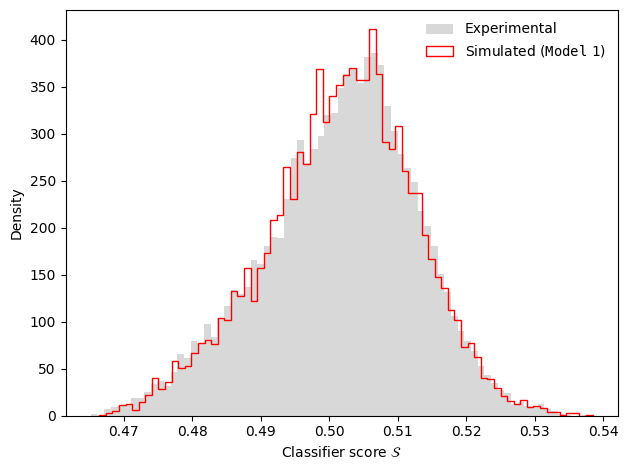

In [ ]:
# Set to eval mode
classifier.eval()

# Extract the scores
exp_scores = torch.sigmoid(classifier.forward(exp_obs[:N_events], device="cpu")).to(device).detach()
sim_scores = torch.sigmoid(classifier.forward(sim_obs[:N_events], device="cpu")).to(device).detach()

print(classifier.forward(exp_obs[:N_events], device="cpu"))
# Plot the classifier scores
fig, ax = plt.subplots(1,1)
ax.hist(exp_scores.cpu().numpy(), bins=75, histtype='stepfilled', label='Experimental', color='gray', alpha=0.3)
ax.hist(sim_scores.cpu().numpy(), bins=75, histtype='step', label=r'Simulated ($\mathtt{Model}$ $\mathtt{1}$)', color='red')
ax.set_xlabel(r'Classifier score $\mathcal{S}$')
ax.set_ylabel('Density')
ax.legend(frameon=False)
fig.tight_layout()

In [ ]:
# Convert into torch objects
sim_scores          = torch.Tensor(sim_scores[0:N_events].clone())
sim_accept_reject = torch.Tensor(sim_accept_reject[0:N_events].copy())
sim_fPrel         = torch.Tensor(sim_fPrel[0:N_events].copy())
exp_scores          = torch.Tensor(exp_scores[0:N_events].clone())

# Check the accepted z-values, if z == 1 reduce it by epsilon (a very nasty bug to find).
# The a-coefficient when computing the likelihood has a term proportional to log(1-z). If 
# z = 1, this term diverges to -inf and completely destroys the backward pass.
epsilon = 1e-5
sim_accept_reject[sim_accept_reject == 1] = 1 - epsilon

# Print dataset shapes
print('Experimental scores shape:', exp_scores.shape)
print('Experimental scores:', exp_scores[:10])
print('Simulated scores shape:', sim_scores.shape)
print('Simulated scores:', sim_scores[:10])
print('Simulated z shape:', sim_accept_reject.shape) # only has the z values, accepted and rejected
# print('Simulated z:', sim_accept_reject[0,0,:])
print('Simulated fPrel shape:', sim_fPrel.shape)

# Prepare data for DataLoader
sim_scores        = ObservableDataset(sim_scores)
sim_accept_reject = ObservableDataset(sim_accept_reject)
sim_mT            = ObservableDataset(sim_fPrel)
exp_scores        = ObservableDataset(exp_scores)

In [ ]:
# Set batch size -- set it eqaul to the number of events, we only want one 'batch'
batch_size = N_events

# Initialize data-loaders
sim_observable_dataloader    = DataLoader(sim_scores,          batch_size = batch_size, shuffle = False)
sim_accept_reject_dataloader = DataLoader(sim_accept_reject, batch_size = batch_size, shuffle = False)
sim_fPrel_dataloader         = DataLoader(sim_fPrel,         batch_size = batch_size, shuffle = False)
exp_observable_dataloader    = DataLoader(exp_scores,          batch_size = batch_size, shuffle = False)

print('Size of sim_observable_dataloader:', len(sim_observable_dataloader.dataset))
print('Size of sim_accept_reject_dataloader:', len(sim_accept_reject_dataloader.dataset))
print('Size of sim_fPrel_dataloader:', len(sim_fPrel_dataloader.dataset))
print('Size of exp_observable_dataloader:', len(exp_observable_dataloader.dataset))
print('Shape of sim_observable_dataloader:', sim_accept_reject_dataloader.dataset.data.shape)